
# <font color= #003366> **Image-to-Sketch Translation using Conditional GANs (Pix2Pix)** </font>
- <Strong> Subject: </Strong>  <font color="blue">`Deep Learning` </font>
- <Strong> Project 2: </Strong>  <font color="blue">`GANs` </font>

<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

___

## <font color=  #003366> **Introducción**</font>

En esta sección se implementa la GAN para convertir imágenes de gatos en sketches

Se utiliza una arquitectura del tipo image-to-image translation, inspirada en Pix2Pix, donde el modelo aprende una entre la entrada que es la foto del gato y su respectiva salida que es el sketch.

El modelo está compuesto por dos redes principales:

Generador: encargado de transformar la imagen real en un sketch.
Discriminador: encargado de distinguir entre sketches reales y generados.

El entrenamiento se basa en una función de pérdida combinada que incluye:

- Una pérdida (GAN), que trata de generar imágenes realistas
- Una pérdida de reconstrucción (L1), que asegura que la salida conserve la estructura de la imagen original.

El dataset de entrenamiento utilizado está estructurado en pares alineados de imágenes (fotografía | sketch), lo que permite al modelo aprender la transformación deseada, mientras que el del test es (A|A)

## <font color=  #003366> **Clonación de Repo**</font>

In [ ]:
!git clone https://github.com/Moni-Ib/Project2_GANs.git
%cd Project2_GANs

Cloning into 'Project2_GANs'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 64 (delta 10), reused 62 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 40.08 KiB | 13.36 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/Project2_GANs


## <font color=  #003366> **Conectar con Drive**</font>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/dataset/cats_final ./dataset

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## <font color=  #003366> **Requirements**</font>

In [ ]:
!pip install torch torchvision opencv-python

In [ ]:
!pip install dominate

## <font color=  #003366> **Entrenamiento del modelo**</font>

In [ ]:
!export PYTHONPATH=$PYTHONPATH:/content/Project2_GANs/src/models/apdrawing_gan && \
python src/models/apdrawing_gan/train.py \
--dataroot /content/Project2_GANs/dataset \
--name cats_pix2pix \
--model apdrawing_gan \
--netG unet_256 \
--dataset_mode aligned \
--which_direction AtoB \
--display_id -1 \
--batch_size 4 \
--niter 25 \
--niter_decay 25 \
--fineSize 256 \
--loadSize 256 \
--gpu_ids 0 \
--lambda_L1 50 \
--num_threads 2

----------------- Options ---------------
                    EYE_H: 40                            
                    EYE_W: 56                            
                  MOUTH_H: 40                            
                  MOUTH_W: 64                            
                   NOSE_H: 48                            
                   NOSE_W: 48                            
                  addw_bg: 1.0                           
                 addw_eye: 1.0                           
                addw_hair: 1.0                           
               addw_mouth: 1.0                           
                addw_nose: 1.0                           
           auxiliary_root: auxiliary                     
               batch_size: 4                             	[default: 1]
                    beta1: 0.5                           
                   bg_dir: dataset/mask/ALL              
          checkpoints_dir: ./checkpoints                 
                 

Para entrenar el modelo se usó una arquitectura basada en Pix2Pix, que sirve para convertir una imagen en otra, en este caso de una foto de gato a un sketch.

El generador es una red tipo U-Net (unet_256), que es importante porque tiene una estructura que conecta las capas iniciales con las finales, lo que ayuda a no perder detalles importantes de la imagen original. Gracias a esto, el modelo puede mantener bien la forma y características del gato en el sketch generado.

Por otro lado, el discriminador se encarga de evaluar si los sketches son reales o generados, lo que hace que el generador tenga que ir mejorando conforme avanza el entrenamiento.

En cuanto a los hiperparámetros, se entrenó el modelo con imágenes de 256×256, usando un batch size de 4, lo cual ayuda a que el entrenamiento sea más estable aunque tarde un poco más.

También se utilizó 25 épocas iniciales y 25 de ajuste un poco más fino, donde en la segunda parte el modelo va ajustando más fino sus pesos.

La función de pérdida combina dos partes: una pérdida GAN, que hace que las imágenes se vean más realistas, y una pérdida L1, que le da bastante peso a que el sketch se parezca a la imagen original en estructura.

En este caso se usó un valor de lambda_L1 = 50, lo que hace que el modelo priorice bastante la similitud con la imagen real. En conjunto, estos parámetros permiten que el modelo aprenda de forma estable y genere sketches coherentes a partir de las fotos.

## <font color=  #003366> **Visualización de Pérdidas**</font>

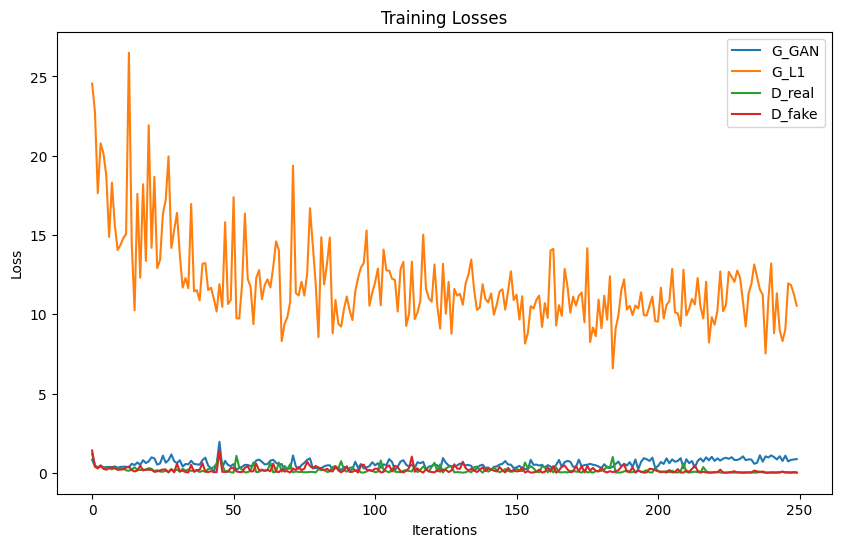

In [ ]:
import re
import matplotlib.pyplot as plt

log_path = './checkpoints/cats_pix2pix/loss_log.txt'

iters = []
G_GAN = []
G_L1 = []
D_real = []
D_fake = []

with open(log_path, 'r') as f:
    for line in f:
        if 'G_GAN' in line:
            iter_num = int(re.search(r'epoch: (\d+), iters: (\d+)', line).group(2))
            iters.append(iter_num)

            G_GAN.append(float(re.search(r'G_GAN: ([\d\.]+)', line).group(1)))
            G_L1.append(float(re.search(r'G_L1: ([\d\.]+)', line).group(1)))
            D_real.append(float(re.search(r'D_real: ([\d\.]+)', line).group(1)))
            D_fake.append(float(re.search(r'D_fake: ([\d\.]+)', line).group(1)))


plt.figure(figsize=(10,6))
plt.plot(G_GAN, label='G_GAN')
plt.plot(G_L1, label='G_L1')
plt.plot(D_real, label='D_real')
plt.plot(D_fake, label='D_fake')

plt.legend()
plt.title('Training Losses')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

## <font color=  #003366> **Test del modelo**</font>

In [ ]:
!export PYTHONPATH=$PYTHONPATH:/content/Project2_GANs/src/models/apdrawing_gan && \
python src/models/apdrawing_gan/test.py \
--dataroot /content/Project2_GANs/dataset \
--name cats_pix2pix \
--model apdrawing_gan \
--netG unet_256 \
--dataset_mode aligned \
--which_direction AtoB \
--phase test \
--num_threads 2 \
--gpu_ids 0

----------------- Options ---------------
                    EYE_H: 40                            
                    EYE_W: 56                            
                  MOUTH_H: 40                            
                  MOUTH_W: 64                            
                   NOSE_H: 48                            
                   NOSE_W: 48                            
             aspect_ratio: 1.0                           
           auxiliary_root: auxiliary                     
               batch_size: 1                             
                   bg_dir: dataset/mask/ALL              
          checkpoints_dir: ./checkpoints                 
                  comb_op: 1                             
                 dataroot: /content/Project2_GANs/dataset	[default: None]
             dataset_mode: aligned                       
              display_env: main                          
               display_id: 1                             
             d

Para la etapa de prueba se usó el modelo ya entrenado para generar sketches a partir de nuevas imágenes que no había visto antes.

En esta parte se carga el generador y se le pasan las imágenes del conjunto de test para ver cómo responde.

El modelo toma cada imagen de entrada y produce su versión en sketch, lo que permite evaluar si realmente aprendió la transformación o solo memorizó los datos de entrenamiento.

Estos resultados se guardan y se pueden comparar visualmente con los sketches reales, lo que ayuda a ver qué tan bien está funcionando el modelo en la práctica.

## <font color=  #003366> **Visualización**</font>

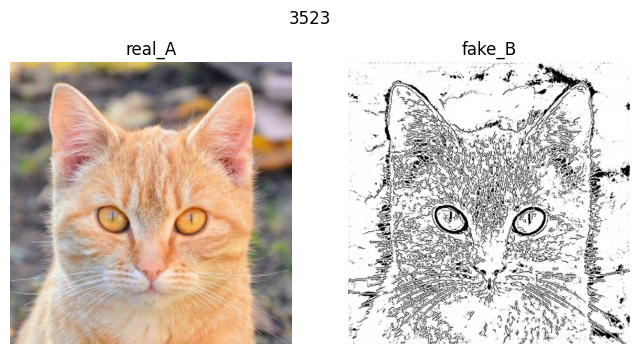

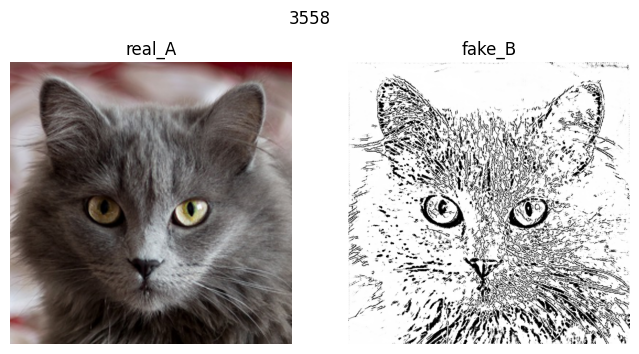

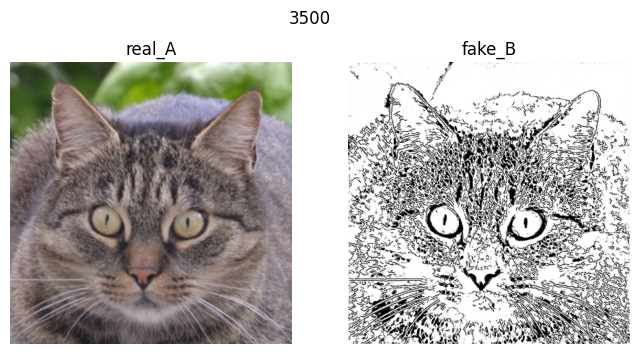

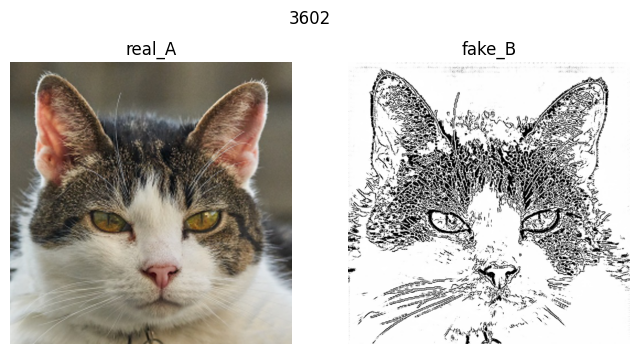

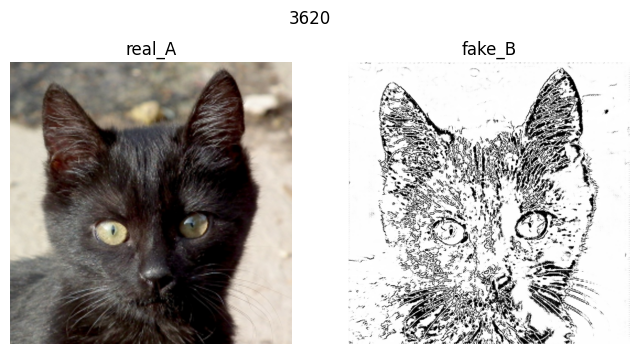

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

folder = "results/cats_pix2pix/test_latest/images"
files = os.listdir(folder)

data = {}

for f in files:
    base = f.split('_')[0]
    if base not in data:
        data[base] = {}

    if "real_A" in f:
        data[base]["real_A"] = f
    elif "fake_B" in f:
        data[base]["fake_B"] = f

count = 0

for key in data:
    if count >= 5:
        break

    if "real_A" in data[key] and "fake_B" in data[key]:

        fig, axs = plt.subplots(1, 2, figsize=(8,4))

        # real
        img_real = Image.open(os.path.join(folder, data[key]["real_A"]))
        axs[0].imshow(img_real)
        axs[0].set_title("real_A")
        axs[0].axis("off")

        # fake
        img_fake = Image.open(os.path.join(folder, data[key]["fake_B"]))
        axs[1].imshow(img_fake)
        axs[1].set_title("fake_B")
        axs[1].axis("off")

        plt.suptitle(key)
        plt.show()

        count += 1

In [ ]:
!zip -r results.zip results/cats_pix2pix/test_latest/images

  adding: results/cats_pix2pix/test_latest/images/ (stored 0%)
  adding: results/cats_pix2pix/test_latest/images/3523_real_A.png (deflated 0%)
  adding: results/cats_pix2pix/test_latest/images/3558_real_A.png (deflated 0%)
  adding: results/cats_pix2pix/test_latest/images/3500_real_A.png (deflated 0%)
  adding: results/cats_pix2pix/test_latest/images/3602_real_A.png (deflated 0%)
  adding: results/cats_pix2pix/test_latest/images/3620_real_B.png (deflated 0%)
  adding: results/cats_pix2pix/test_latest/images/3498_real_B.png (deflated 0%)
  adding: results/cats_pix2pix/test_latest/images/3502_fake_B.png (deflated 6%)
  adding: results/cats_pix2pix/test_latest/images/3558_fake_B.png (deflated 8%)
  adding: results/cats_pix2pix/test_latest/images/3480_real_A.png (deflated 0%)
  adding: results/cats_pix2pix/test_latest/images/3592_fake_B.png (deflated 7%)
  adding: results/cats_pix2pix/test_latest/images/3522_real_B.png (deflated 1%)
  adding: results/cats_pix2pix/test_latest/images/3488_re

Con esta gráfica podemos ver la comparación de la imagen real del gato, el skectch real y el sketch fake generado

## <font color=  #003366> **Next Steps**</font>

En el siguiente experimento se probará el modelo con el conjunto de imágenes en el formato de (A|B) y no (A|A) para poder obtener métricas como FID y poder hacer la comparación entre el sketch real y el fake